# Tobac analysis of LWP

## Notes on Datastructure 

- **field**:
input datafield as an xarray.DataArray (eg. sodt_t or tqc_dia)
- **Features**:
Result of feature detection ( via feature_detection_multithreshold): point features per timestep (DataFrame). Includes time/frame, position (lat, lon), threshold_value. No cell areas yet—just points.
- **Mask_field**:
Result of segmentation (via segmentation_2D): label mask as an xarray.DataArray with the same space/time dims. Per time: 0 = background, >0 = object ID (cell). (can derive cell sizes by counting pixels per ID)
- **Features_field**:
Second return from segmentation_2D: an enriched Features DataFrame that links point features to their object info (e.g., cell ID and ncells = number of pixels in the cell). Use this to get sizes directly (area = ncells × pixel_area)

In [1]:
# system libs
import os, sys, glob
import datetime

import tobac
import xarray as xr    
import numpy as np
if not hasattr(np, "int"):   np.int = int   # use this for the np.int problem

import matplotlib.pyplot as plt

print("numpy:", np.__version__) #np.int which was removed in nuumpy version 2.x.x which is needed for convert_timevec tool (solution: downgraded np-version to <2 in the tobac env)
print("tobac:", tobac.__version__)

print("Python:", sys.executable)
assert "conda/envs/tobac" in sys.executable, "Not using the tobac kernel — switch to 'tobac (Levante)'."


# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

import warnings
warnings.simplefilter("ignore")

numpy: 1.26.4
tobac: 1.6.1
Python: /work/bb1376/user/daniel/conda/envs/tobac/bin/python


## Open Datasets

In [2]:
# Path
#sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar1-20240806-exp010'
sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp010'
#sim_path = '/work/bb1376/user/daniel/icon-build/experiments/cesar3-20241110-exp010'


In [3]:
#cloud variables
ds_2dicon1cloud = xr.open_mfdataset(f'{sim_path}/2d_cloud_DOM01_ML_????????T????00Z_regrid0005d.nc')
ds_2dicon2cloud = xr.open_mfdataset(f'{sim_path}/2d_cloud_DOM02_ML_????????T????00Z_regrid0005d.nc')
ds_2dicon3cloud = xr.open_mfdataset(f'{sim_path}/2d_cloud_DOM03_ML_????????T????00Z_regrid0005d.nc')

sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


In [4]:
datasets2dcloud = {
    "exp010 icon d1 cloud": ds_2dicon1cloud,
    "exp010 icon d2 cloud": ds_2dicon2cloud,
    "exp010 icon d3 cloud": ds_2dicon3cloud,
}

In [5]:
# Define Lindenberg coordinates:
lon_lind, lat_lind = 14.11845, 52.20967

# Define the spatial range over Lindenberg:
lat_min, lat_max = 51.85, 52.55    
lon_min, lon_max = 13.65, 14.55 

# Apply spatial selection to all datasets
for datasets in [datasets2dcloud]:
    for name, ds in datasets.items():
        datasets[name] = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))


In [6]:
# Format time 
for name, ds in datasets2dcloud.items():
    ds['time'] = convert_timevec(ds.time.data)

In [7]:
ds_2dicon1cloud

<xarray.Dataset> Size: 628MB
Dimensions:        (time: 7, plev: 1, bnds: 2, plev_2: 1, plev_3: 1, lat: 1001,
                    lon: 1601)
Coordinates:
  * time           (time) float64 56B 2.024e+07 2.024e+07 ... 2.024e+07
  * lon            (lon) float64 13kB 10.0 10.01 10.01 10.02 ... 17.99 18.0 18.0
  * lat            (lat) float64 8kB 50.0 50.01 50.01 50.02 ... 54.99 54.99 55.0
  * plev           (plev) float64 8B 0.0
  * plev_2         (plev_2) float64 8B 400.0
  * plev_3         (plev_3) float64 8B 800.0
Dimensions without coordinates: bnds
Data variables: (12/17)
    plev_bnds      (time, plev, bnds) float64 112B dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    plev_2_bnds    (time, plev_2, bnds) float64 112B dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    plev_3_bnds    (time, plev_3, bnds) float64 112B dask.array<chunksize=(1, 1, 2), meta=np.ndarray>
    tqv_dia        (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    tqc_dia        (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    tqi_dia        (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    ...             ...
    cape           (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    cape_ml        (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    cin_ml         (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    rain_con_rate  (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    prec_con       (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
    prec_gsp       (time, lat, lon) float32 45MB dask.array<chunksize=(1, 1001, 1601), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    source:       version: 2024.10; revision: icon-2024.10-public-0-ga1324166...
    history:      /home/b/b383413/workspace/icon-build/bin/icon at 20250815 1...
    references:   see MPIM/DWD publications
    comment:      Daniel Kloster (b383413) on l10114 (Linux 4.18.0-513.24.1.e...

## LWP (tqc_dia)

In [8]:
# pick one domain to start 
ds_dom1 = datasets2dcloud["exp010 icon d1 cloud"]
ds_dom2 = datasets2dcloud["exp010 icon d2 cloud"]
ds_dom3 = datasets2dcloud["exp010 icon d3 cloud"]

#define field for upward shortwave flux at TOA
field_dom1 = ds_dom1["tqc_dia"] 
field_dom2 = ds_dom2["tqc_dia"]
field_dom3 = ds_dom3["tqc_dia"] 

In [9]:
field = field_dom1

In [10]:
field

<xarray.DataArray 'tqc_dia' (time: 7, lat: 141, lon: 181)> Size: 715kB
dask.array<getitem, shape=(7, 141, 181), dtype=float32, chunksize=(1, 141, 181), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 56B 2024-09-28T12:00:00 ... 2024-09-28T18:...
  * lon      (lon) float64 1kB 13.65 13.65 13.66 13.67 ... 14.54 14.54 14.55
  * lat      (lat) float64 1kB 51.85 51.85 51.86 51.87 ... 52.54 52.55 52.55
Attributes:
    standard_name:  tqc_dia
    long_name:      total column integrated cloud water (diagnostic)
    units:          kg m**-2
    param:          215.1.0

### Plot Map and Histogram

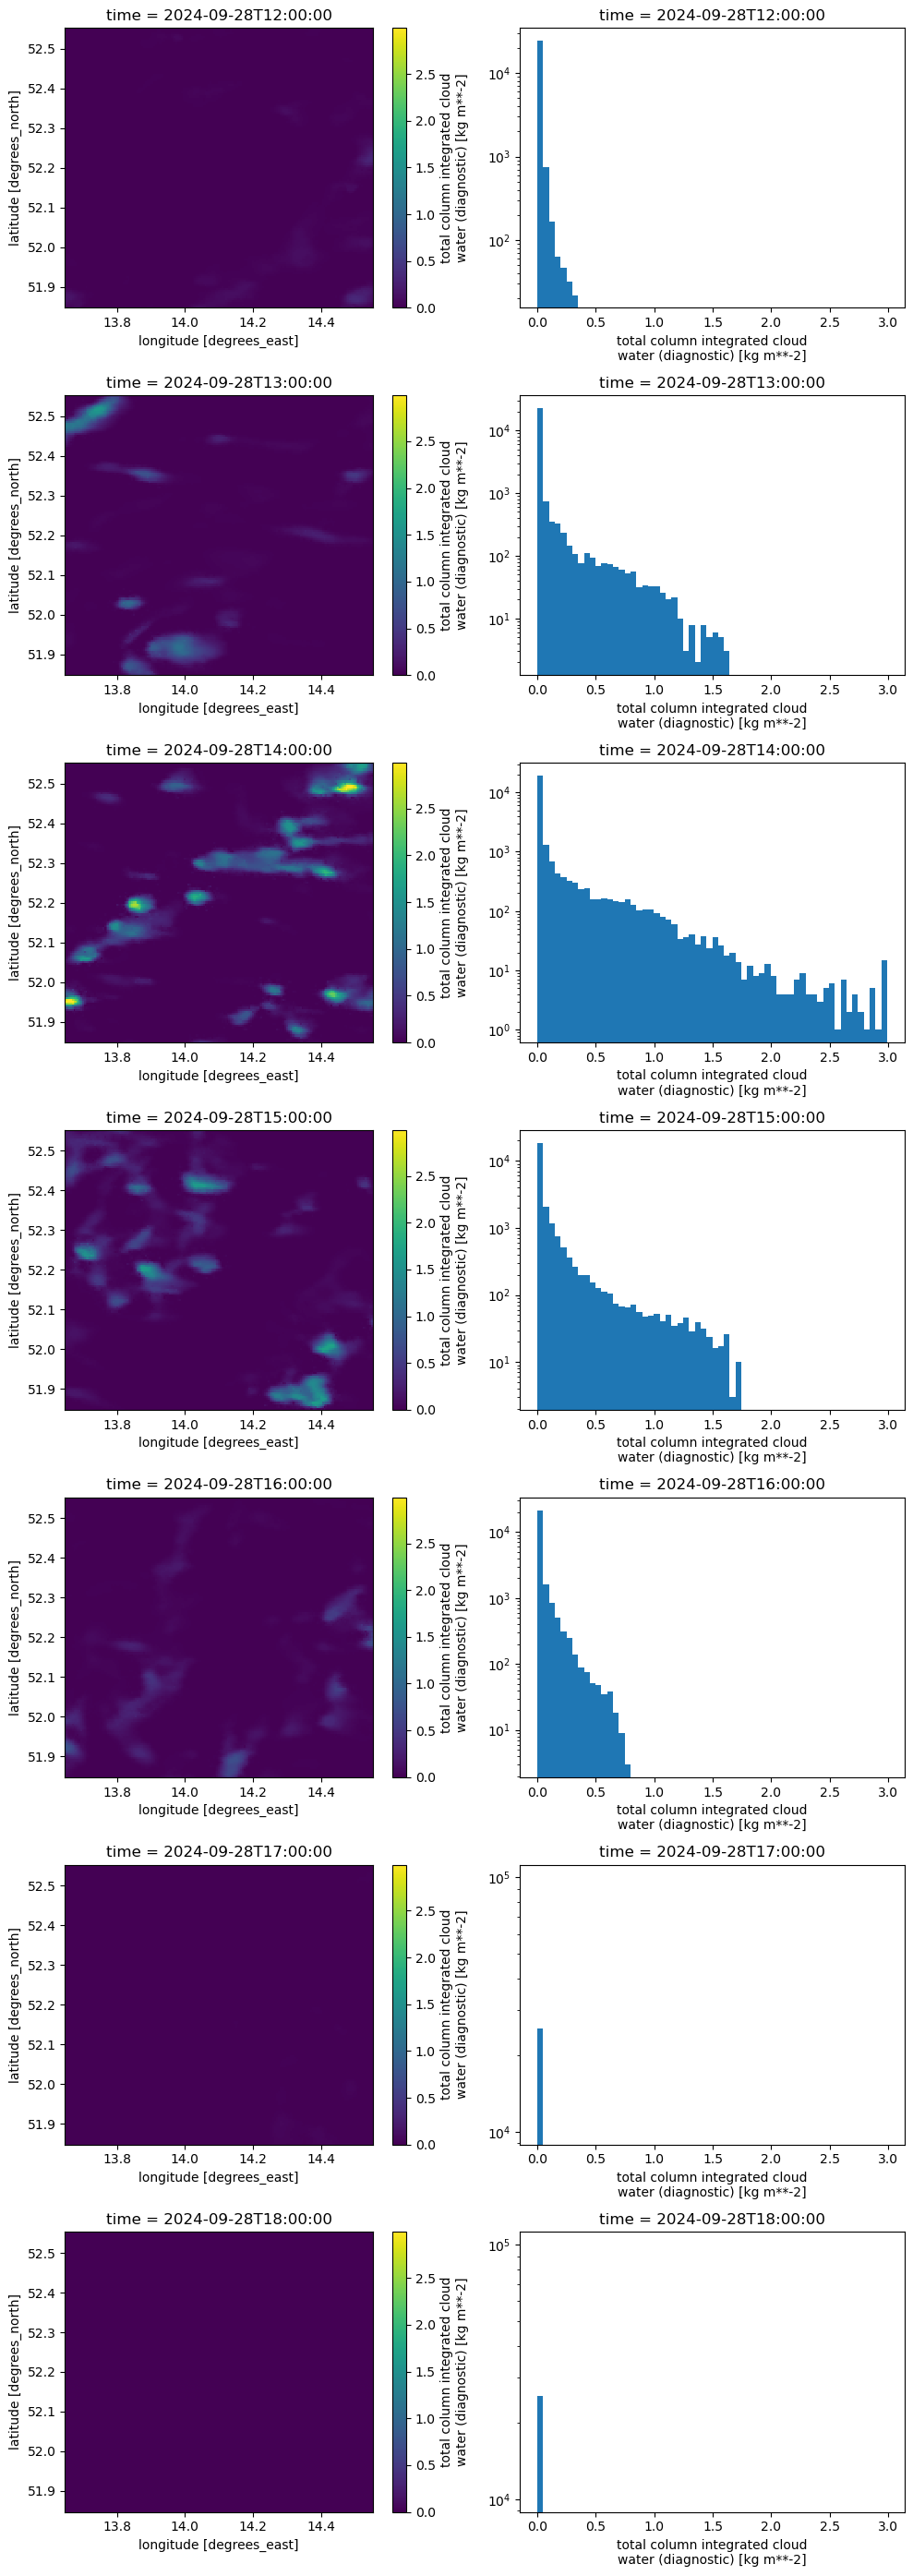

In [11]:
field = field_dom1

# time indices
idxs = [0,1,2,3,4,5,6]
idxs = [i for i in idxs if i < field.sizes["time"]]

#shared color limits across all rows (simple: min/max over those frames)
sub = field.isel(time=idxs)
vmin = float(sub.min())
vmax = float(sub.max())

# plot
fig, axs = plt.subplots(ncols=2, nrows=len(idxs), figsize=(10, 4*len(idxs)))
plt.subplots_adjust(hspace=0.5)

for i, itime in enumerate(idxs):
    # left: map with shared clim
    im = field.isel(time=itime).plot(ax=axs[i, 0], vmin=vmin, vmax=vmax)
    #im.colorbar.set_label("upward shortwave flux at TOA [W m-2]")  # rename cbar

    # right: histogram (same x-range for consistency)
    field.isel(time=itime).plot.hist(ax=axs[i, 1], bins=60, range=(vmin, vmax))
    #axs[i, 1].set_xlabel("upward shortwave flux at TOA [W m-2]")  # rename xlabel
    axs[i, 1].set_yscale("log")

plt.tight_layout()



## get spacings manually (dxy, dt)
tobac.utils.get_spacings() needs x-y data not lat-lon

In [12]:
field_cp = field.copy()

# mean latitude to convert lon->meters
lat0 = float(field_cp.lat.mean())
print(lat0)

# median step sizes in degrees 
dlat_deg = float(abs(field_cp.lat.diff("lat").median()))
dlon_deg = float(abs(field_cp.lon.diff("lon").median()))

# degrees -> meters (Earth-mean approximations)
m_per_deg_lat = 110_574.0
m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

dy = dlat_deg * m_per_deg_lat
dx = dlon_deg * m_per_deg_lon


# one representative horizontal spacing (meters)
dxy = float(np.sqrt(dx * dy))   # geometric mean (area-preserving)
print(f"dxy ≈ {dxy:.1f} m (dx={dx:.1f}, dy={dy:.1f})")

#timesteps (seconds)
dt = float((field_cp.time.diff('time') / np.timedelta64(1, 's')).median().item())
print(f"dt = {dt} s")

52.199999999999996
dxy ≈ 434.3 m (dx=341.1, dy=552.9)
dt = 3600.0 s


## Feature detection (multiple treshhold)

In [13]:
# Dictionary containing keyword arguments for feature detection step
parameters_features={}
parameters_features['position_threshold']='weighted_diff'
parameters_features['sigma_threshold']=0.5
parameters_features['n_min_threshold']=4
#parameters_features['target']='minimum'
parameters_features['target']='maximum'
parameters_features['threshold']=[0.5,1,1.5,2,2.5]

In [14]:
# Perform feature detection:
print('starting feature detection')
Features = tobac.feature_detection_multithreshold(field, dxy, **parameters_features)
#Features.to_hdf(savedir / 'Features.h5', 'table')
print('feature detection performed')

starting feature detection
feature detection performed


In [15]:
Features

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,lon,lat
0,1,1,3.555014,39.081770,64,0.5,1,2024-09-28 13:00:00,2024-09-28 13:00:00,13.845409,51.867775
1,1,3,35.647114,36.925179,41,0.5,2,2024-09-28 13:00:00,2024-09-28 13:00:00,13.834626,52.028236
2,1,4,100.797985,46.451205,38,0.5,3,2024-09-28 13:00:00,2024-09-28 13:00:00,13.882256,52.353990
3,1,7,13.213045,66.794009,24,1.0,4,2024-09-28 13:00:00,2024-09-28 13:00:00,13.983970,51.916065
4,1,10,133.123299,18.939051,12,1.5,5,2024-09-28 13:00:00,2024-09-28 13:00:00,13.744695,52.515616
5,2,2,12.814925,104.681261,42,0.5,6,2024-09-28 14:00:00,2024-09-28 14:00:00,14.173406,51.914075
6,2,4,19.448773,176.734540,54,0.5,7,2024-09-28 14:00:00,2024-09-28 14:00:00,14.533673,51.947244
7,2,15,128.844292,64.567375,60,0.5,8,2024-09-28 14:00:00,2024-09-28 14:00:00,13.972837,52.494221
8,2,17,5.892119,135.695559,14,1.0,9,2024-09-28 14:00:00,2024-09-28 14:00:00,14.328478,51.879461
9,2,20,25.789032,122.188570,12,1.0,10,2024-09-28 14:00:00,2024-09-28 14:00:00,14.260943,51.978945


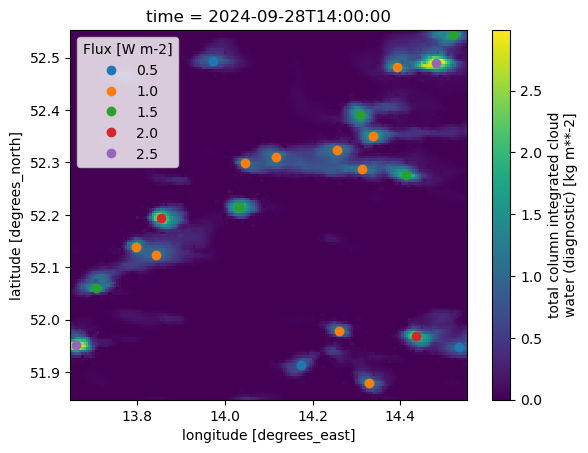

In [16]:
#Plot
frame=2

#field[frame].plot(cmap="binary") #black and white cmap
field[frame].plot()
points = {
    threshold:plt.plot(ft.lon, ft.lat, "o")[0]
    for threshold, ft in Features[Features.frame==frame].groupby("threshold_value")
}
plt.legend(list(points.values()), list(points.keys()), title="Flux [W m-2]")


## Segmentation

In [17]:
# Dictionary containing keyword options for the segmentation step:
parameters_segmentation={}
parameters_segmentation['target']='maximum'
parameters_segmentation['method']='watershed'
parameters_segmentation['threshold']=0.5


In [18]:
# Perform segmentation and save results:
print('Starting segmentation based on field.')
Mask_field, Features_field = tobac.segmentation_2D(Features, field, dxy, **parameters_segmentation)
print('segmentation performed')
#Mask_OLR.to_netcdf(savedir / 'Mask_Segmentation_OLR.nc', encoding={"segmentation_mask":{"zlib":True, "complevel":4}})
#Features_OLR.to_hdf(savedir / 'Features_OLR.h5', 'table')

Starting segmentation based on field.
segmentation performed


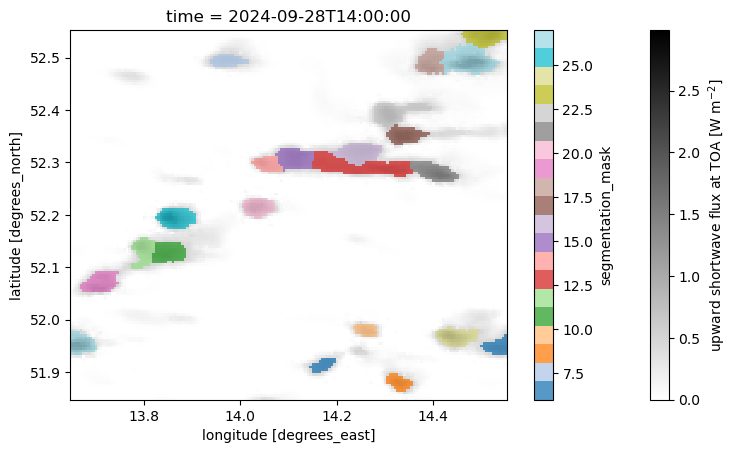

In [19]:
#Plot
plt.figure(figsize=(8.8, 4.8))
field[frame].plot(cmap="binary", cbar_kwargs={"label": "upward shortwave flux at TOA [W m$^{-2}$]"})
Mask_field[frame].where(Mask_field[frame]>0).plot(cmap="tab20", alpha=0.75)


## Notes on Datastructure

- **field**:
input datafield as an xarray.DataArray (eg. sodt_t or tqc_dia)
- **Features**:
Result of feature detection ( via feature_detection_multithreshold): point features per timestep (DataFrame). Includes time/frame, position (lat, lon), threshold_value. No cell areas yet—just points.
- **Mask_field**:
Result of segmentation (via segmentation_2D): label mask as an xarray.DataArray with the same space/time dims. Per time: 0 = background, >0 = object ID (cell). (can derive cell sizes by counting pixels per ID)
- **Features_field**:
Second return from segmentation_2D: an enriched Features DataFrame that links point features to their object info (e.g., cell ID and ncells = number of pixels in the cell). Use this to get sizes directly (area = ncells × pixel_area)


## Cell-size- distribution 

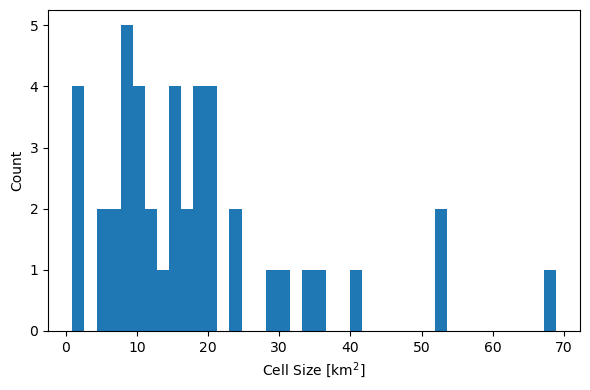

In [20]:
#total distibution across all frames
sizes=Features_field["ncells"] * (dxy**2) # m² per cell

# histogram (cell-size distribution)
plt.figure(figsize=(6,4))
plt.hist(sizes/1e6, bins=40) # convert to km²
plt.xlabel("Cell Size [km$^2$]"); plt.ylabel("Count")
#plt.yscale("log")  
plt.tight_layout() 
plt.show()

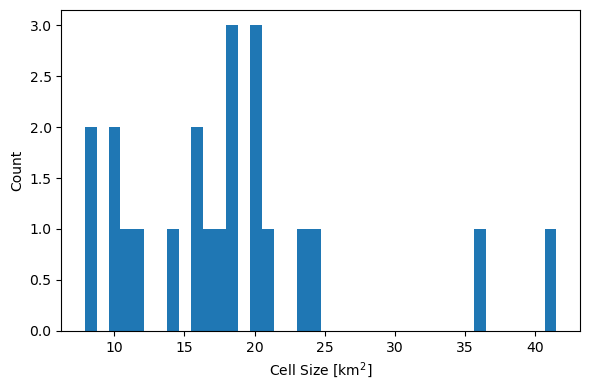

In [21]:
# distribution in indivudual frame
frame = 2  
sizes = Features_field.loc[Features_field["frame"] == frame, "ncells"] * (dxy**2)  # m²

plt.figure(figsize=(6,4))
plt.hist(sizes/1e6, bins=40)  # km²
plt.xlabel("Cell Size [km$^2$]"); plt.ylabel("Count")
# plt.yscale("log")
plt.tight_layout()
plt.show()


## Domain comparison of cell size distribution


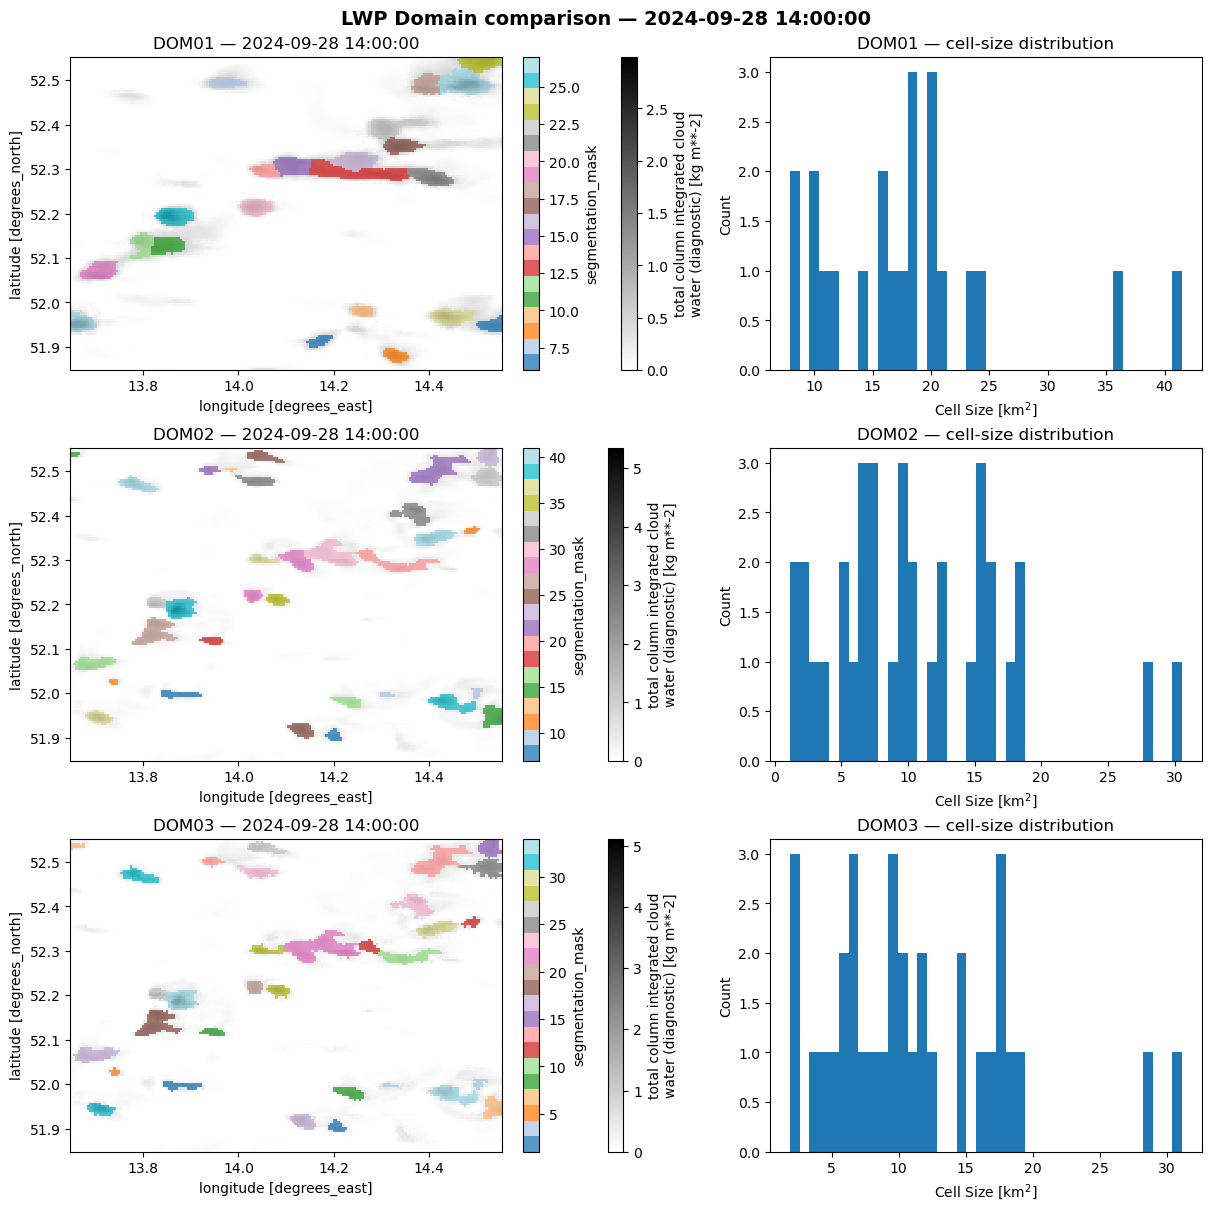

In [22]:
time= "2024-09-28 14:00:00"
domains = [("DOM01", field_dom1), ("DOM02", field_dom2), ("DOM03", field_dom3)]

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), constrained_layout=True)
fig.suptitle(f"LWP Domain comparison — {time}", fontsize=14, fontweight="bold")
for i, (name, field) in enumerate(domains):    
    # Perform feature detection:
    Features = tobac.feature_detection_multithreshold(field, dxy, **parameters_features)

    # Perform segmentation:
    Mask_field, Features_field = tobac.segmentation_2D(Features, field, dxy, **parameters_segmentation)

    # LEFT: field (with colorbar label) + mask overlay
    #field[frame].plot(ax=axs[i,0], cmap="binary")
    #Mask_field[frame].where(Mask_field[frame]>0).plot(ax=axs[i,0], cmap="tab20", alpha=0.75)

    # plot by timestamp, not by frame , becasue frames do not align (different starting points for domains)
    field.sel(time=time).plot(ax=axs[i,0], cmap="binary")
    Mask_field.sel(time=time).where(Mask_field.sel(time=time)>0).plot(ax=axs[i,0], cmap="tab20", alpha=0.75)
    #axs[i,0}set_title(f
    
    # RIGHT: histogram of cell sizes
    sizes = Features_field.loc[Features_field["time"] == time, "ncells"] * (dxy**2)  # m²
    axs[i,1].hist(np.asarray(sizes)/1e6, bins=40)  # km²
    axs[i,1].set_xlabel("Cell Size [km$^2$]")
    axs[i,1].set_ylabel("Count")

    #Titles
    axs[i,0].set_title(f"{name} — {time}")
    axs[i,1].set_title(f"{name} — cell-size distribution")

plt.show()
